In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH      = "../data/processed/severity_data.csv"
RAW_PATH       = "../data/raw/complaints.csv"
OUT_FIG        = "../outputs/figures"
OUT_REPORT_DIR = "../outputs/reports"
for d in [OUT_FIG, OUT_REPORT_DIR]: os.makedirs(d, exist_ok=True)

CLUSTER_LABELS = {
    0: "Credit Report Disputes",
    1: "Debt Collection & Recovery",
    2: "Card Payments & Account Calls",
}

ANOMALY_SIGMA = 2.0

print("Setup complete")

Setup complete


In [2]:
df = pd.read_csv(DATA_PATH)

CHUNK_SIZE = 100_000
raw_cols = ["Consumer complaint narrative", "Date received"]

target_narratives = set(df["narrative"].dropna().unique())
print(f"Looking up dates for {len(target_narratives):,} unique narratives")

matched_chunks = []
total_scanned = 0

for chunk in pd.read_csv(
    RAW_PATH,
    usecols=raw_cols,
    chunksize=CHUNK_SIZE,
    low_memory=False,
    parse_dates=["Date received"],
):
    chunk = chunk.rename(columns={
        "Consumer complaint narrative": "narrative",
        "Date received": "date_received",
    })
    chunk = chunk.dropna(subset=["date_received", "narrative"])
    chunk = chunk[chunk["narrative"].isin(target_narratives)]

    if not chunk.empty:
        matched_chunks.append(chunk)

    total_scanned += CHUNK_SIZE
    if total_scanned % 1_000_000 == 0:
        matched_so_far = sum(len(c) for c in matched_chunks)
        print(f"  Scanned {total_scanned:>12,} rows | matched: {matched_so_far:,}")

raw_df = (pd.concat(matched_chunks, ignore_index=True)
          .drop_duplicates(subset="narrative", keep="first"))
print(f"Total matched: {len(raw_df):,}")

df = df.merge(raw_df, on="narrative", how="left")
df["date_received"] = pd.to_datetime(df["date_received"], errors="coerce")
df["month"] = df["date_received"].dt.to_period("M")

missing_dates = df["date_received"].isna().sum()
print(f"Rows with timestamps: {df['date_received'].notna().sum():,} | missing: {missing_dates:,}")
print(f"Date range: {df['date_received'].min().date()} to {df['date_received'].max().date()}")

Looking up dates for 17,181 unique narratives
  Scanned    1,000,000 rows | matched: 33,921
  Scanned    2,000,000 rows | matched: 67,862
  Scanned    3,000,000 rows | matched: 101,489
  Scanned    4,000,000 rows | matched: 135,338
  Scanned    5,000,000 rows | matched: 169,413
  Scanned    6,000,000 rows | matched: 203,071
  Scanned    7,000,000 rows | matched: 236,799
  Scanned    8,000,000 rows | matched: 270,562
  Scanned    9,000,000 rows | matched: 304,133
  Scanned   10,000,000 rows | matched: 338,071
  Scanned   11,000,000 rows | matched: 372,016
  Scanned   12,000,000 rows | matched: 405,967
  Scanned   13,000,000 rows | matched: 440,384
  Scanned   14,000,000 rows | matched: 474,411
Total matched: 17,181
Rows with timestamps: 17,181 | missing: 0
Date range: 2015-03-19 to 2026-04-02


Months analysed: 126 (range: 2015-04 to 2026-02)


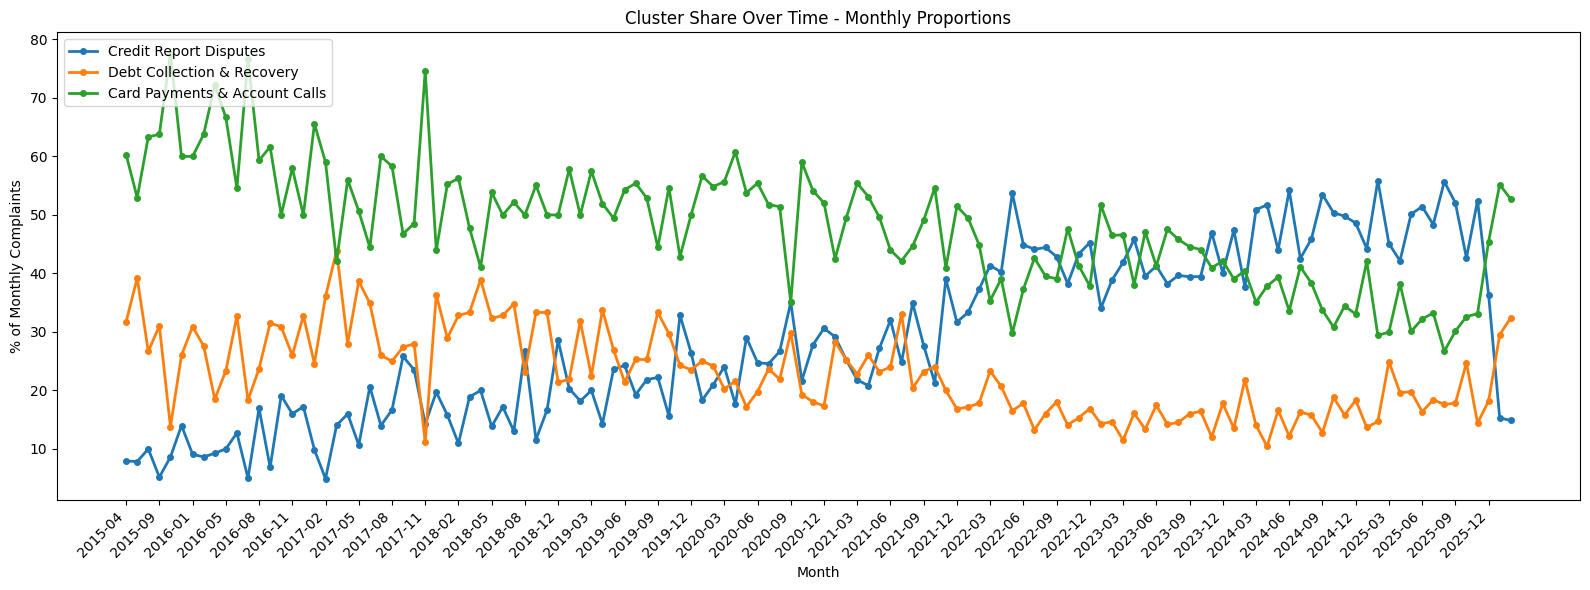

In [3]:
monthly = (
    df.dropna(subset=["month"])
    .groupby(["month", "cluster"])
    .size()
    .unstack(fill_value=0)
    .rename(columns=CLUSTER_LABELS)
)

monthly_pct = monthly.div(monthly.sum(axis=1), axis=0) * 100
monthly_pct.index = monthly_pct.index.astype(str)

total_per_month = monthly.sum(axis=1)
valid_months = total_per_month[total_per_month >= 50].index.astype(str)
monthly_pct = monthly_pct.loc[valid_months]

print(f"Months analysed: {len(monthly_pct)} (range: {monthly_pct.index[0]} to {monthly_pct.index[-1]})")

fig, ax = plt.subplots(figsize=(16, 6))
colors = sns.color_palette("tab10", len(CLUSTER_LABELS))
for i, col in enumerate(monthly_pct.columns):
    ax.plot(monthly_pct.index, monthly_pct[col], "o-", lw=2,
            color=colors[i], label=col, markersize=4)

ax.set(xlabel="Month", ylabel="% of Monthly Complaints",
       title="Cluster Share Over Time - Monthly Proportions")
ax.legend(loc="upper left")
ax.set_xticks(monthly_pct.index[::3])
ax.set_xticklabels(monthly_pct.index[::3], rotation=45, ha="right")
plt.tight_layout()
plt.savefig(f"{OUT_FIG}/09_temporal_trends.png", dpi=150, bbox_inches="tight")
plt.show()

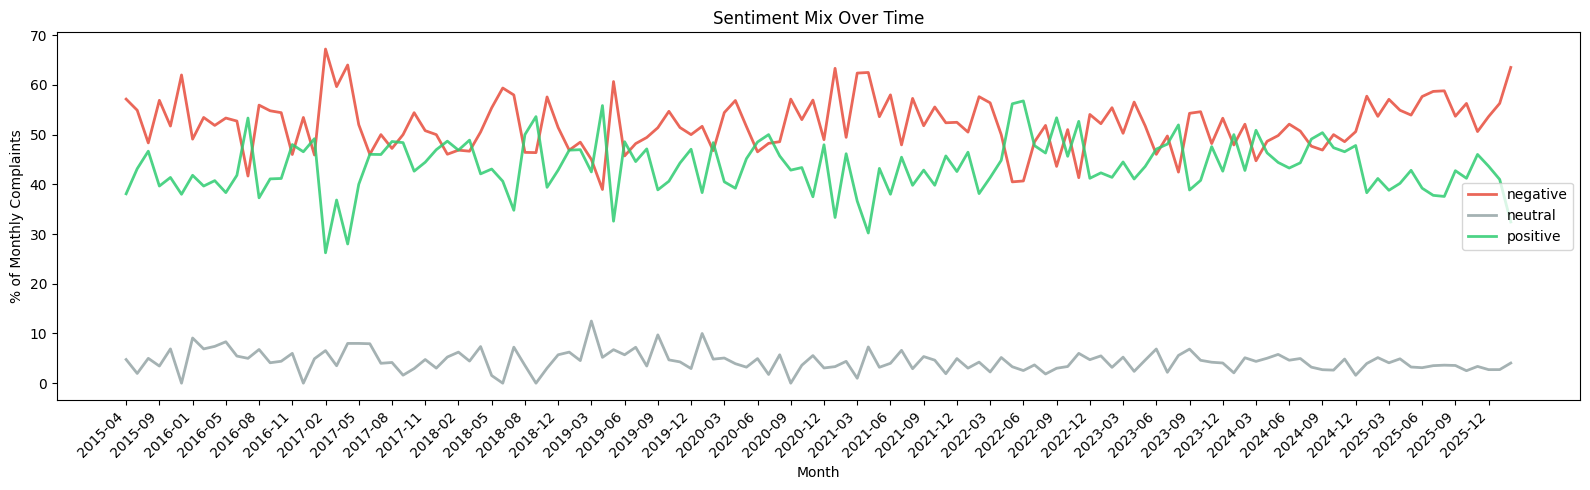

In [4]:
sentiment_monthly = (
    df.dropna(subset=["month"])
    .groupby(["month", "sentiment"])
    .size()
    .unstack(fill_value=0)
)
sentiment_monthly_pct = sentiment_monthly.div(sentiment_monthly.sum(axis=1), axis=0) * 100
sentiment_monthly_pct.index = sentiment_monthly_pct.index.astype(str)
sentiment_monthly_pct = sentiment_monthly_pct.loc[
    sentiment_monthly_pct.index.isin(valid_months)
]

fig, ax = plt.subplots(figsize=(16, 5))
sent_colors = {"negative": "#e74c3c", "neutral": "#95a5a6", "positive": "#2ecc71"}
for sent, color in sent_colors.items():
    if sent in sentiment_monthly_pct.columns:
        ax.plot(sentiment_monthly_pct.index, sentiment_monthly_pct[sent],
                lw=2, color=color, label=sent, alpha=0.85)

ax.set(xlabel="Month", ylabel="% of Monthly Complaints",
       title="Sentiment Mix Over Time")
ax.legend()
ax.set_xticks(sentiment_monthly_pct.index[::3])
ax.set_xticklabels(sentiment_monthly_pct.index[::3], rotation=45, ha="right")
plt.tight_layout()
plt.savefig(f"{OUT_FIG}/09_sentiment_trend.png", dpi=150, bbox_inches="tight")
plt.show()

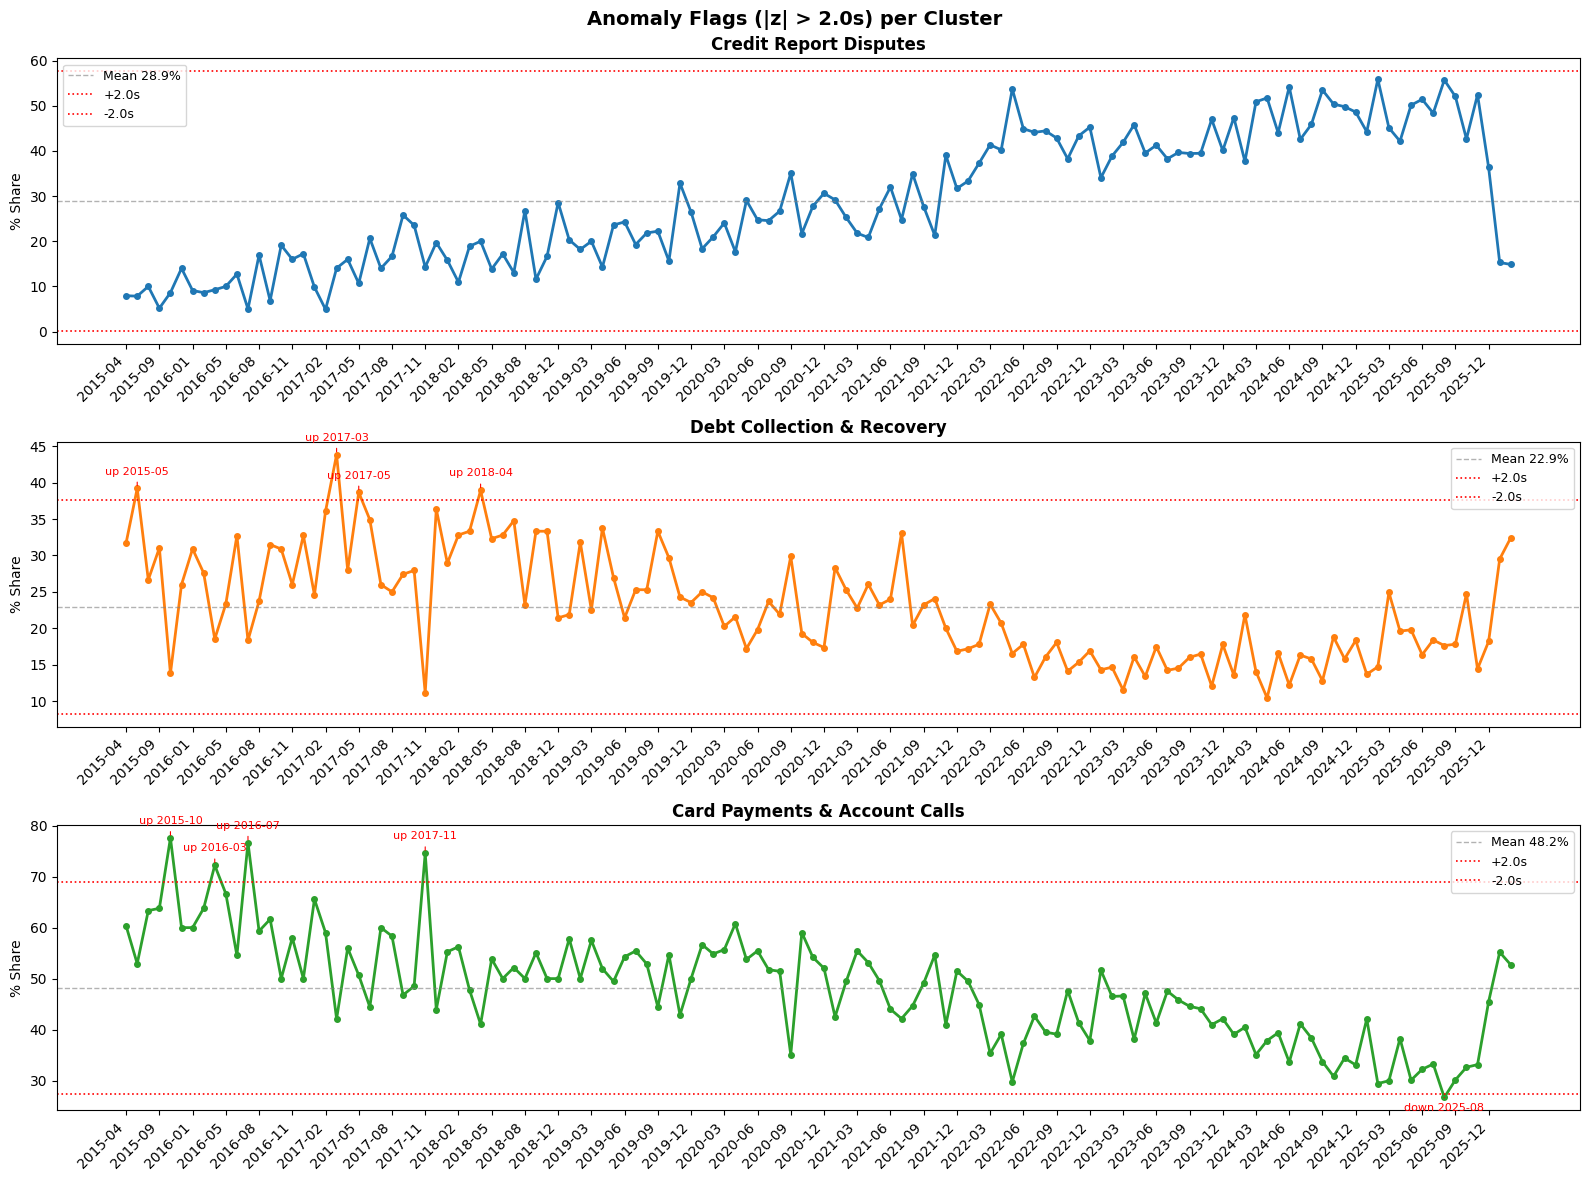

9 anomalies detected:
  month                       cluster  value  z_score direction
2017-03    Debt Collection & Recovery  43.86     2.84     spike
2015-10 Card Payments & Account Calls  77.59     2.83     spike
2016-07 Card Payments & Account Calls  76.67     2.74     spike
2017-11 Card Payments & Account Calls  74.60     2.54     spike
2016-03 Card Payments & Account Calls  72.22     2.31     spike
2015-05    Debt Collection & Recovery  39.22     2.21     spike
2018-04    Debt Collection & Recovery  38.95     2.17     spike
2017-05    Debt Collection & Recovery  38.67     2.14     spike
2025-08 Card Payments & Account Calls  26.68    -2.06      drop


In [5]:
anomalies = []

fig, axes = plt.subplots(len(CLUSTER_LABELS), 1, figsize=(16, 4 * len(CLUSTER_LABELS)))

for idx, col in enumerate(monthly_pct.columns):
    series = monthly_pct[col]
    mu     = series.mean()
    sigma  = series.std()

    z_scores = (series - mu) / sigma
    flagged  = z_scores[z_scores.abs() > ANOMALY_SIGMA]

    ax = axes[idx]
    ax.plot(series.index, series.values, "o-", lw=2, color=colors[idx], markersize=4)
    ax.axhline(mu, color="gray", linestyle="--", lw=1, alpha=0.6, label=f"Mean {mu:.1f}%")
    ax.axhline(mu + ANOMALY_SIGMA * sigma, color="red", linestyle=":", lw=1.2, label=f"+{ANOMALY_SIGMA}s")
    ax.axhline(mu - ANOMALY_SIGMA * sigma, color="red", linestyle=":", lw=1.2, label=f"-{ANOMALY_SIGMA}s")

    for m in flagged.index:
        v = series[m]
        direction = "up" if v > mu else "down"
        ax.annotate(f"{direction} {m}", xy=(m, v),
                    xytext=(0, 10 * (1 if v > mu else -1)),
                    textcoords="offset points", fontsize=8, color="red",
                    ha="center", arrowprops=dict(arrowstyle="-", color="red", lw=0.8))
        anomalies.append({
            "month": m, "cluster": col,
            "value": round(v, 2), "z_score": round(float(z_scores[m]), 2),
            "direction": "spike" if v > mu else "drop"
        })

    ax.set_title(col, fontsize=12, fontweight="bold")
    ax.set_xticks(series.index[::3])
    ax.set_xticklabels(series.index[::3], rotation=45, ha="right")
    ax.legend(fontsize=9)
    ax.set_ylabel("% Share")

plt.suptitle(f"Anomaly Flags (|z| > {ANOMALY_SIGMA}s) per Cluster", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUT_FIG}/09_anomaly_flags.png", dpi=150, bbox_inches="tight")
plt.show()

anomaly_df = pd.DataFrame(anomalies)
if not anomaly_df.empty:
    print(f"{len(anomaly_df)} anomalies detected:")
    print(anomaly_df.sort_values("z_score", key=abs, ascending=False).to_string(index=False))
else:
    print("No anomalies detected at the current threshold.")

In [6]:
trend_report = monthly_pct.copy()
trend_report.index.name = "month"
trend_report["total_complaints"] = monthly.sum(axis=1).loc[valid_months].values

report_path = f"{OUT_REPORT_DIR}/trend_report.csv"
trend_report.reset_index().to_csv(report_path, index=False)
print(f"Trend report saved: {report_path}")

if not anomaly_df.empty:
    anomaly_path = f"{OUT_REPORT_DIR}/anomaly_flags.csv"
    anomaly_df.to_csv(anomaly_path, index=False)
    print(f"Anomaly report saved: {anomaly_path}")

Trend report saved: ../outputs/reports/trend_report.csv
Anomaly report saved: ../outputs/reports/anomaly_flags.csv
